# RepNet Hybrid Model Analysis

**Goal**: Analyze the best model from Optuna optimization
1. Visualize learned convolutional kernels at each stage
2. Check if kernels detect ECG features (P, QRS, T waves)
3. Run inference on example cases
4. Generate Grad-CAM saliency maps to understand model attention

In [1]:
import sys
sys.path.append("..")

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from pathlib import Path
import json

from src.models.repnet_hybrid import RepNetHybrid
from src.data.dataset import load_seniordesign
from src.preprocessing.filters import NotchFilter, BaselineWanderFilter
from src.preprocessing.normalization import ZScoreNormalization

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

C:\Users\ahmed\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load Best Model

In [2]:
# Load model parameters
MODEL_DIR = Path("../optuna/2026-04-17_00-37-13")
with open(MODEL_DIR / "best_params.json") as f:
    params_info = json.load(f)

params = params_info["full_params"]
params["stage_filters"] = tuple(params["stage_filters"])  # convert list to tuple
print("Model parameters:")
for k, v in params.items():
    print(f"  {k}: {v}")

# Initialize model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = RepNetHybrid(**{k: v for k, v in params.items() if k in [
    "stage_filters", "wide_kernel", "narrow_kernel", "dropout", "n_heads"
]}).to(device)

# Load weights
state_dict = torch.load(MODEL_DIR / "best_model.pt", map_location=device)
model.load_state_dict(state_dict)
model.eval()

print(f"\nModel loaded on {device}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

Model parameters:
  stage_filters: (32, 64)
  wide_kernel: 7
  narrow_kernel: 5
  n_heads: 4
  batch_size: 64
  epochs: 50
  loss_fn: weighted
  lr: 0.0008756917546352803
  dropout: 0.06355381998641418

Model loaded on cpu
Total parameters: 116,802


## 2. Visualize Convolutional Kernels

Check if learned kernels resemble ECG feature detectors:
- Stage 1 (wide kernels, k=7): Should capture low-frequency patterns (P-wave, T-wave)
- Stage 2 (narrow kernels, k=5): Should capture sharper features (QRS complex)

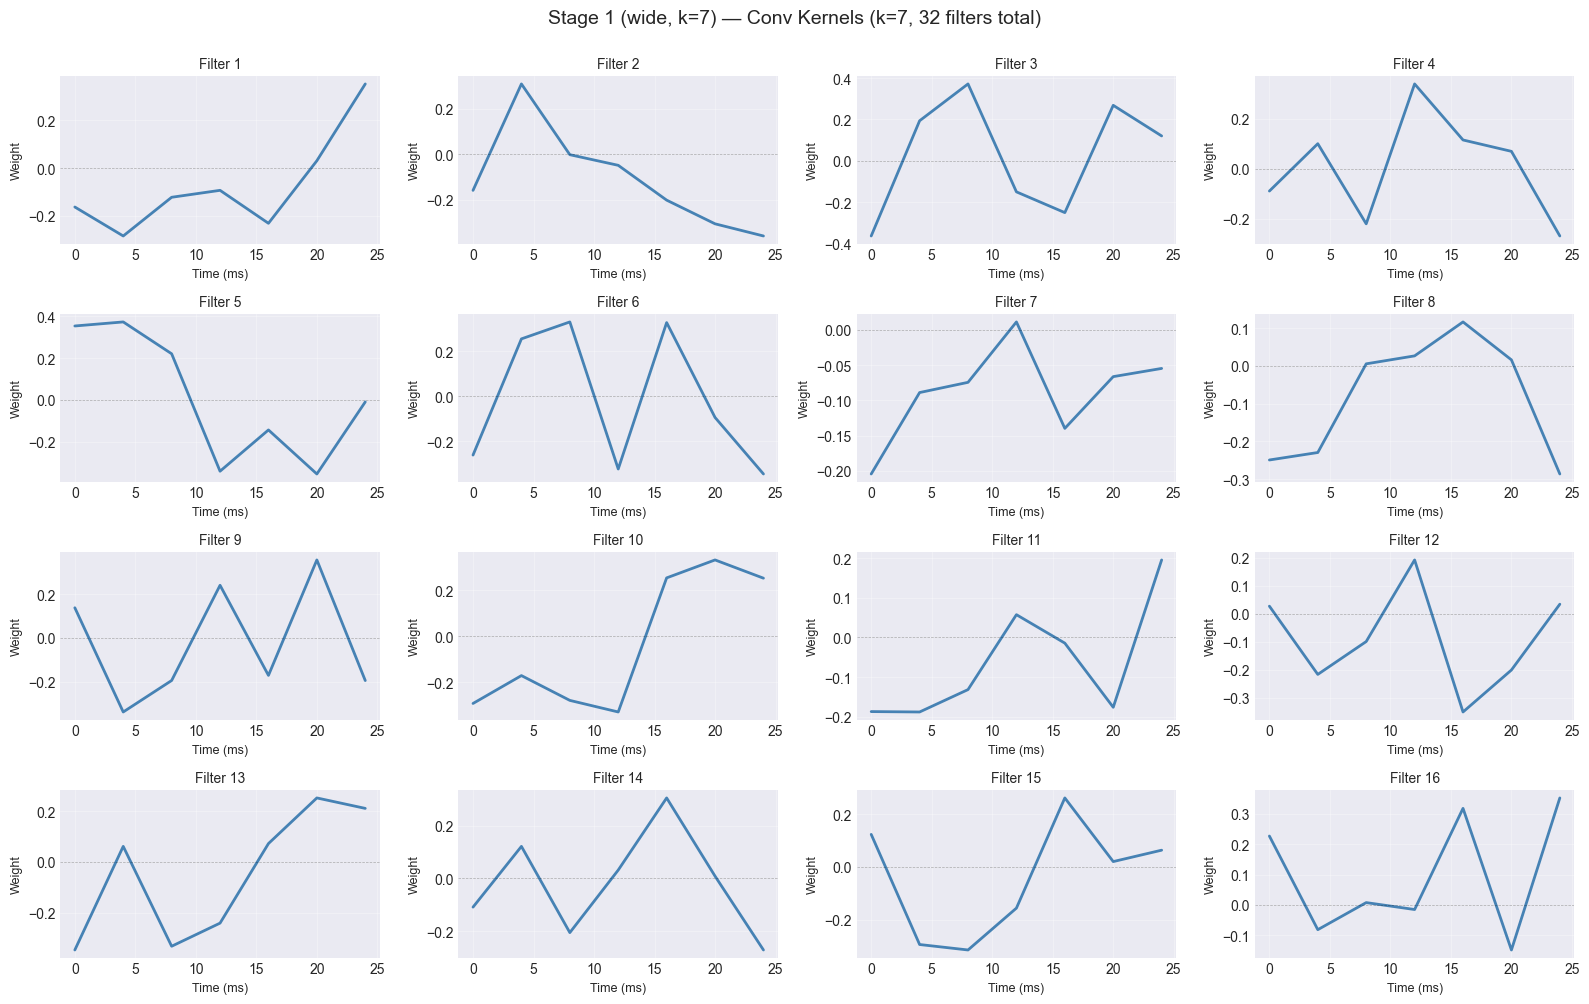

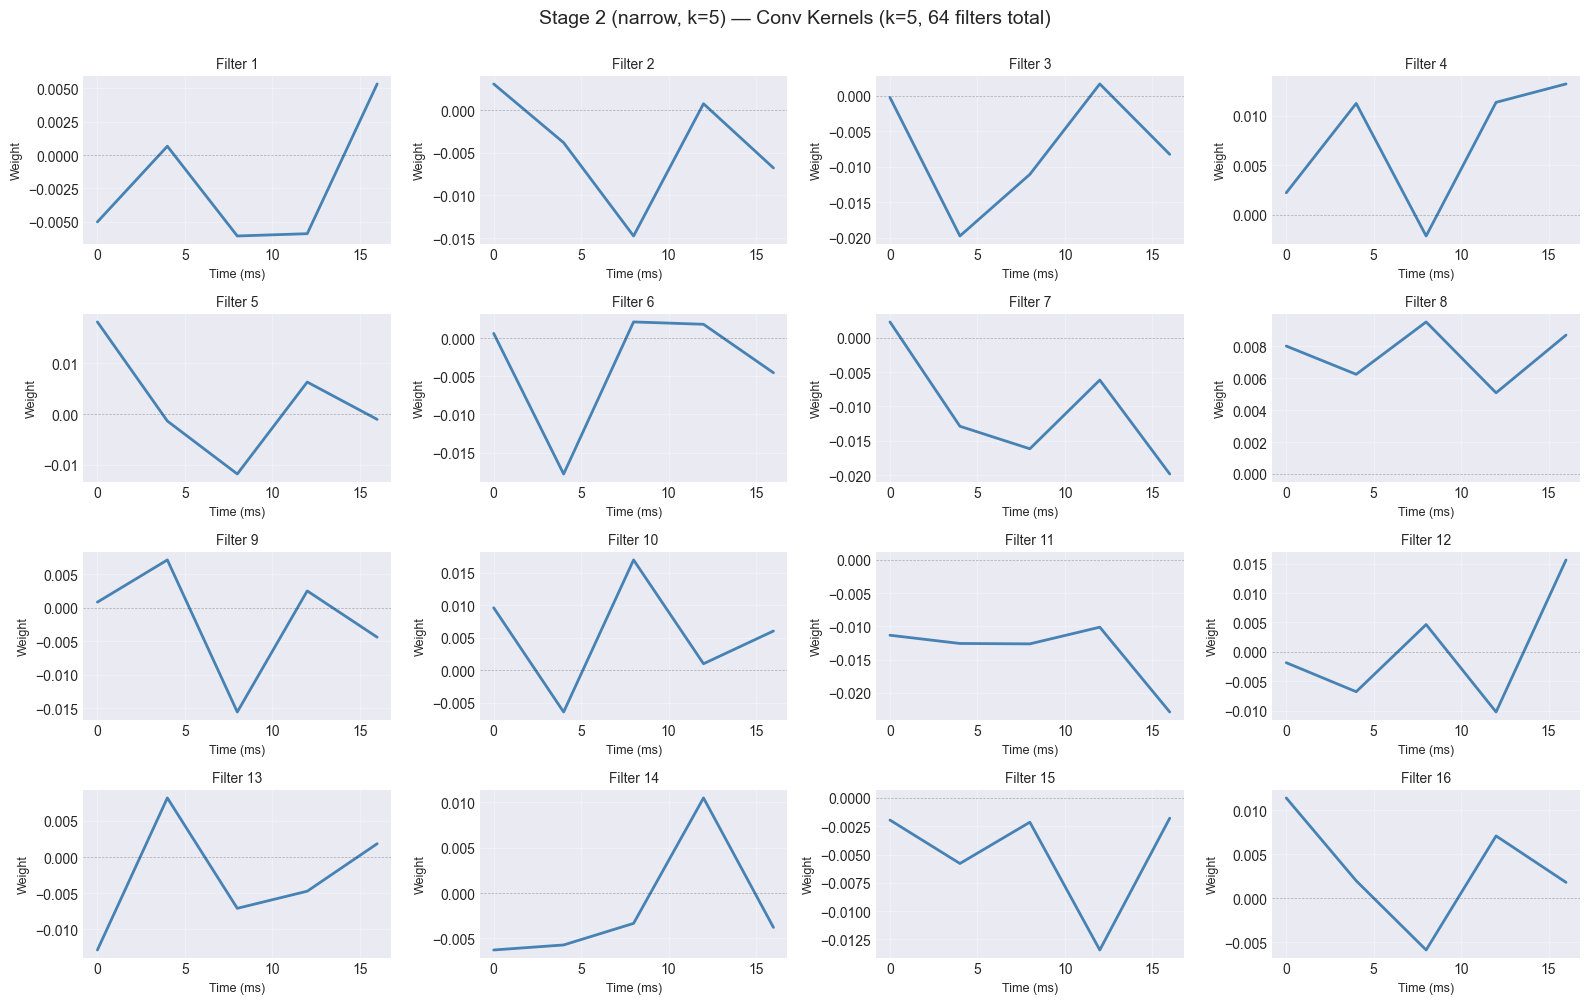

In [3]:
def plot_conv_kernels(model, stage_name, conv_layer, n_filters=16, fs=250.0):
    """
    Visualize convolutional kernels from a layer.
    
    Args:
        model: RepNetHybrid model
        stage_name: e.g., "Stage 1" or "Stage 2"
        conv_layer: The conv layer (e.g., model.conv1.conv1)
        n_filters: Number of filters to visualize
        fs: Sampling frequency (Hz)
    """
    # Get kernel weights: (out_channels, in_channels, kernel_size)
    weights = conv_layer.weight.detach().cpu().numpy()
    out_ch, in_ch, k_size = weights.shape
    
    # Time axis in milliseconds
    t_ms = np.arange(k_size) / fs * 1000
    
    n_show = min(n_filters, out_ch)
    n_cols = 4
    n_rows = (n_show + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 2.5))
    axes = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else axes
    
    for i in range(n_show):
        ax = axes[i]
        # Average over input channels (for stage 1, in_ch=1)
        kernel = weights[i].mean(axis=0)
        ax.plot(t_ms, kernel, linewidth=2, color='steelblue')
        ax.axhline(0, color='k', linewidth=0.5, linestyle='--', alpha=0.3)
        ax.set_title(f"Filter {i+1}", fontsize=10)
        ax.set_xlabel("Time (ms)", fontsize=9)
        ax.set_ylabel("Weight", fontsize=9)
        ax.grid(True, alpha=0.3)
    
    # Hide unused subplots
    for j in range(n_show, len(axes)):
        axes[j].axis('off')
    
    plt.suptitle(f"{stage_name} — Conv Kernels (k={k_size}, {out_ch} filters total)", 
                 fontsize=14, y=1.00)
    plt.tight_layout()
    plt.show()

# Stage 1: Wide kernels (k=7, ~28ms at 250Hz)
plot_conv_kernels(model, "Stage 1 (wide, k=7)", model.conv1.conv1, n_filters=16)

# Stage 2: Narrow kernels (k=5, ~20ms at 250Hz)
plot_conv_kernels(model, "Stage 2 (narrow, k=5)", model.conv2.conv1, n_filters=16)

### Frequency Response of Kernels

Compute FFT of kernels to see what frequencies they respond to (should align with EDA finding of 1 Hz discriminative peak)

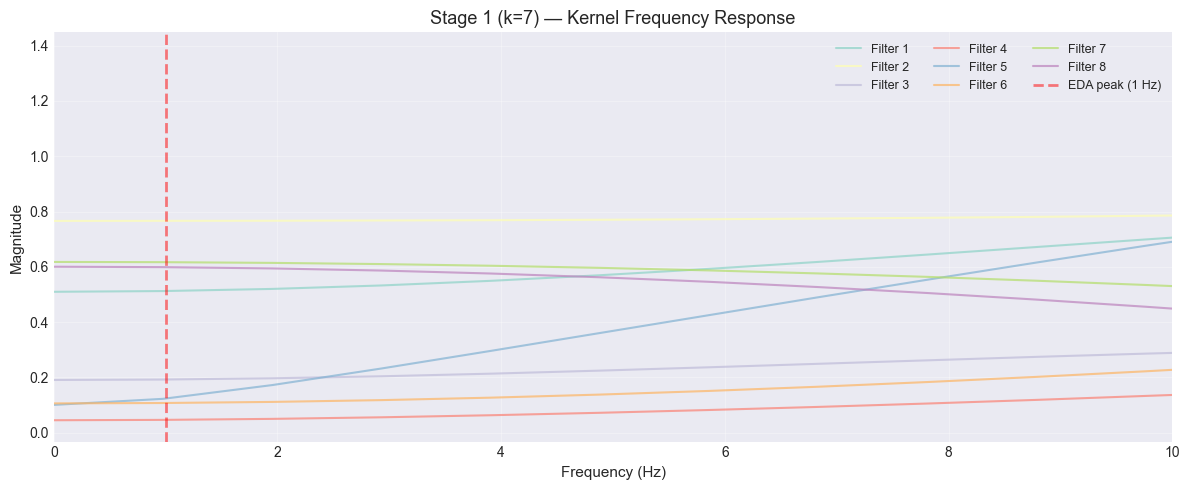

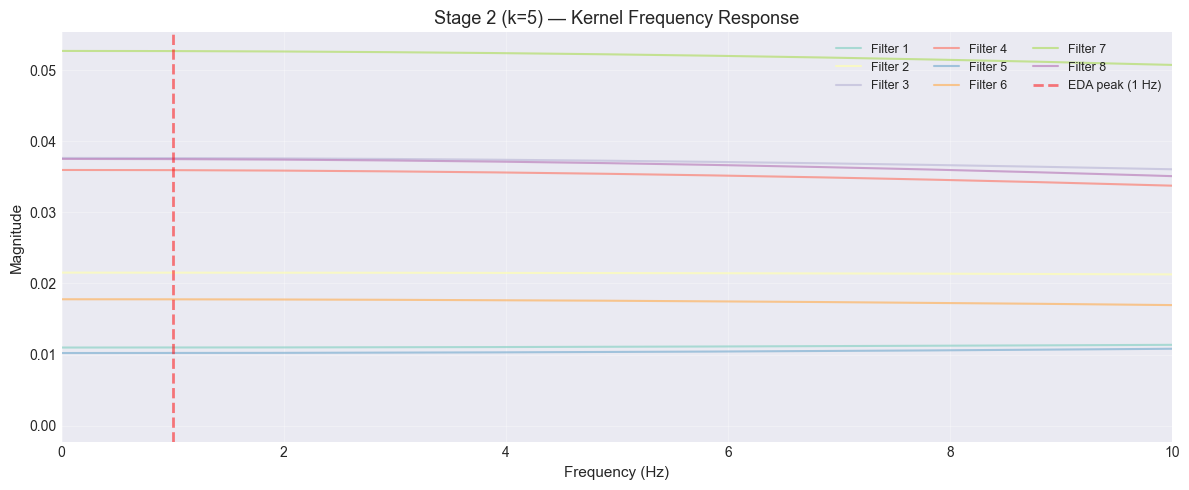

In [4]:
def plot_kernel_frequency_response(conv_layer, stage_name, n_filters=8, fs=250.0):
    """
    Plot frequency response (FFT magnitude) of convolutional kernels.
    """
    weights = conv_layer.weight.detach().cpu().numpy()
    out_ch, in_ch, k_size = weights.shape
    
    n_show = min(n_filters, out_ch)
    fig, ax = plt.subplots(figsize=(12, 5))
    
    for i in range(n_show):
        kernel = weights[i].mean(axis=0)  # average over input channels
        # Zero-pad for smoother FFT
        kernel_padded = np.pad(kernel, (0, 256 - k_size), mode='constant')
        fft = np.fft.rfft(kernel_padded)
        freqs = np.fft.rfftfreq(len(kernel_padded), d=1/fs)
        magnitude = np.abs(fft)
        
        ax.plot(freqs, magnitude, alpha=0.7, linewidth=1.5, label=f"Filter {i+1}")
    
    ax.axvline(1.0, color='red', linestyle='--', linewidth=2, alpha=0.5, 
               label='EDA peak (1 Hz)')
    ax.set_xlim(0, 10)  # Focus on low frequencies
    ax.set_xlabel("Frequency (Hz)", fontsize=11)
    ax.set_ylabel("Magnitude", fontsize=11)
    ax.set_title(f"{stage_name} — Kernel Frequency Response", fontsize=13)
    ax.legend(ncol=3, fontsize=9, loc='upper right')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_kernel_frequency_response(model.conv1.conv1, "Stage 1 (k=7)")
plot_kernel_frequency_response(model.conv2.conv1, "Stage 2 (k=5)")

## 3. Load Test Data

In [5]:
# Load and preprocess data
# Note: balanced dataset uses metadata_balanced.csv, so we'll use a workaround
import shutil
from pathlib import Path

DATA_DIR = Path("../data/seniordesign_upload_balanced")

# Create symlink or copy if metadata.csv doesn't exist
if not (DATA_DIR / "metadata.csv").exists():
    shutil.copy(DATA_DIR / "metadata_balanced.csv", DATA_DIR / "metadata.csv")
    print("Created metadata.csv from metadata_balanced.csv")

X, y = load_seniordesign(str(DATA_DIR))

# Apply same preprocessing as training
X, _ = BaselineWanderFilter(cutoff=0.5, order=4, fs=250.0).transform(X)
X, _ = NotchFilter(freq=60.0, Q=30.0, fs=250.0).transform(X)
X, _ = ZScoreNormalization(per_lead=True).transform(X)

print(f"Loaded {len(X)} samples")
print(f"Class distribution: {np.sum(y==0)} normal, {np.sum(y==1)} preeclampsia")

Created metadata.csv from metadata_balanced.csv
Loaded 369 samples
Class distribution: 182 normal, 187 preeclampsia


## 4. Run Inference on Examples

In [6]:
# Get predictions for all samples
with torch.no_grad():
    X_tensor = torch.tensor(X, dtype=torch.float32).to(device)
    logits = model(X_tensor)
    probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()  # P(preeclampsia)

# Find interesting examples
normal_idx = np.where(y == 0)[0]
preeclampsia_idx = np.where(y == 1)[0]

# High confidence correct predictions
confident_normal = normal_idx[np.argsort(probs[normal_idx])[:5]]  # lowest probs
confident_preeclampsia = preeclampsia_idx[np.argsort(probs[preeclampsia_idx])[-5:]]  # highest probs

# Uncertain predictions (near 0.5)
uncertain_idx = np.argsort(np.abs(probs - 0.5))[:5]

print("High confidence NORMAL predictions:")
for idx in confident_normal:
    print(f"  Sample {idx}: P(PE)={probs[idx]:.4f}  (true label: {y[idx]})")

print("\nHigh confidence PREECLAMPSIA predictions:")
for idx in confident_preeclampsia:
    print(f"  Sample {idx}: P(PE)={probs[idx]:.4f}  (true label: {y[idx]})")

print("\nUncertain predictions (near 0.5):")
for idx in uncertain_idx:
    print(f"  Sample {idx}: P(PE)={probs[idx]:.4f}  (true label: {y[idx]})")

High confidence NORMAL predictions:
  Sample 261: P(PE)=0.0004  (true label: 0)
  Sample 233: P(PE)=0.0009  (true label: 0)
  Sample 246: P(PE)=0.0010  (true label: 0)
  Sample 287: P(PE)=0.0015  (true label: 0)
  Sample 255: P(PE)=0.0016  (true label: 0)

High confidence PREECLAMPSIA predictions:
  Sample 109: P(PE)=0.9997  (true label: 1)
  Sample 13: P(PE)=0.9999  (true label: 1)
  Sample 141: P(PE)=0.9999  (true label: 1)
  Sample 56: P(PE)=0.9999  (true label: 1)
  Sample 72: P(PE)=1.0000  (true label: 1)

Uncertain predictions (near 0.5):
  Sample 368: P(PE)=0.4992  (true label: 0)
  Sample 204: P(PE)=0.5025  (true label: 0)
  Sample 230: P(PE)=0.4876  (true label: 0)
  Sample 78: P(PE)=0.4851  (true label: 1)
  Sample 318: P(PE)=0.4841  (true label: 0)


## 5. Grad-CAM Saliency Maps

Visualize which temporal regions and leads the model focuses on for prediction.

We'll implement Grad-CAM for the final convolutional layer before fusion.

In [7]:
class GradCAM:
    """
    Grad-CAM implementation for RepNetHybrid.
    
    Target layer: model.conv2 (final per-lead conv before fusion)
    """
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        # Register hooks
        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_full_backward_hook(self.save_gradient)
    
    def save_activation(self, module, input, output):
        self.activations = output.detach()
    
    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()
    
    def __call__(self, x, class_idx=1):
        """
        Generate Grad-CAM for input x.
        
        Args:
            x: Input tensor (batch, 12, 2500)
            class_idx: Target class (1 = preeclampsia)
        
        Returns:
            cam: (batch, 12, T) saliency map for each lead
        """
        self.model.eval()
        
        # Forward pass
        logits = self.model(x)
        
        # Backward pass for target class
        self.model.zero_grad()
        class_score = logits[:, class_idx]
        class_score.backward(torch.ones_like(class_score))
        
        # Get gradients and activations
        # activations: (B, L, C, T)  gradients: (B, L, C, T)
        grads = self.gradients
        acts = self.activations
        
        # Global average pooling over time: importance weights per channel
        # weights: (B, L, C)
        weights = grads.mean(dim=-1, keepdim=True)  # (B, L, C, 1)
        
        # Weighted combination of activation maps
        cam = (weights * acts).sum(dim=2)  # (B, L, T)
        
        # ReLU and normalize per lead
        cam = torch.relu(cam)
        for b in range(cam.shape[0]):
            for l in range(cam.shape[1]):
                cam_max = cam[b, l].max()
                if cam_max > 0:
                    cam[b, l] /= cam_max
        
        return cam.cpu().numpy()

# Initialize Grad-CAM
gradcam = GradCAM(model, model.conv2)
print("Grad-CAM initialized on model.conv2")

Grad-CAM initialized on model.conv2


### Visualize Grad-CAM on Example Cases

High confidence NORMAL prediction


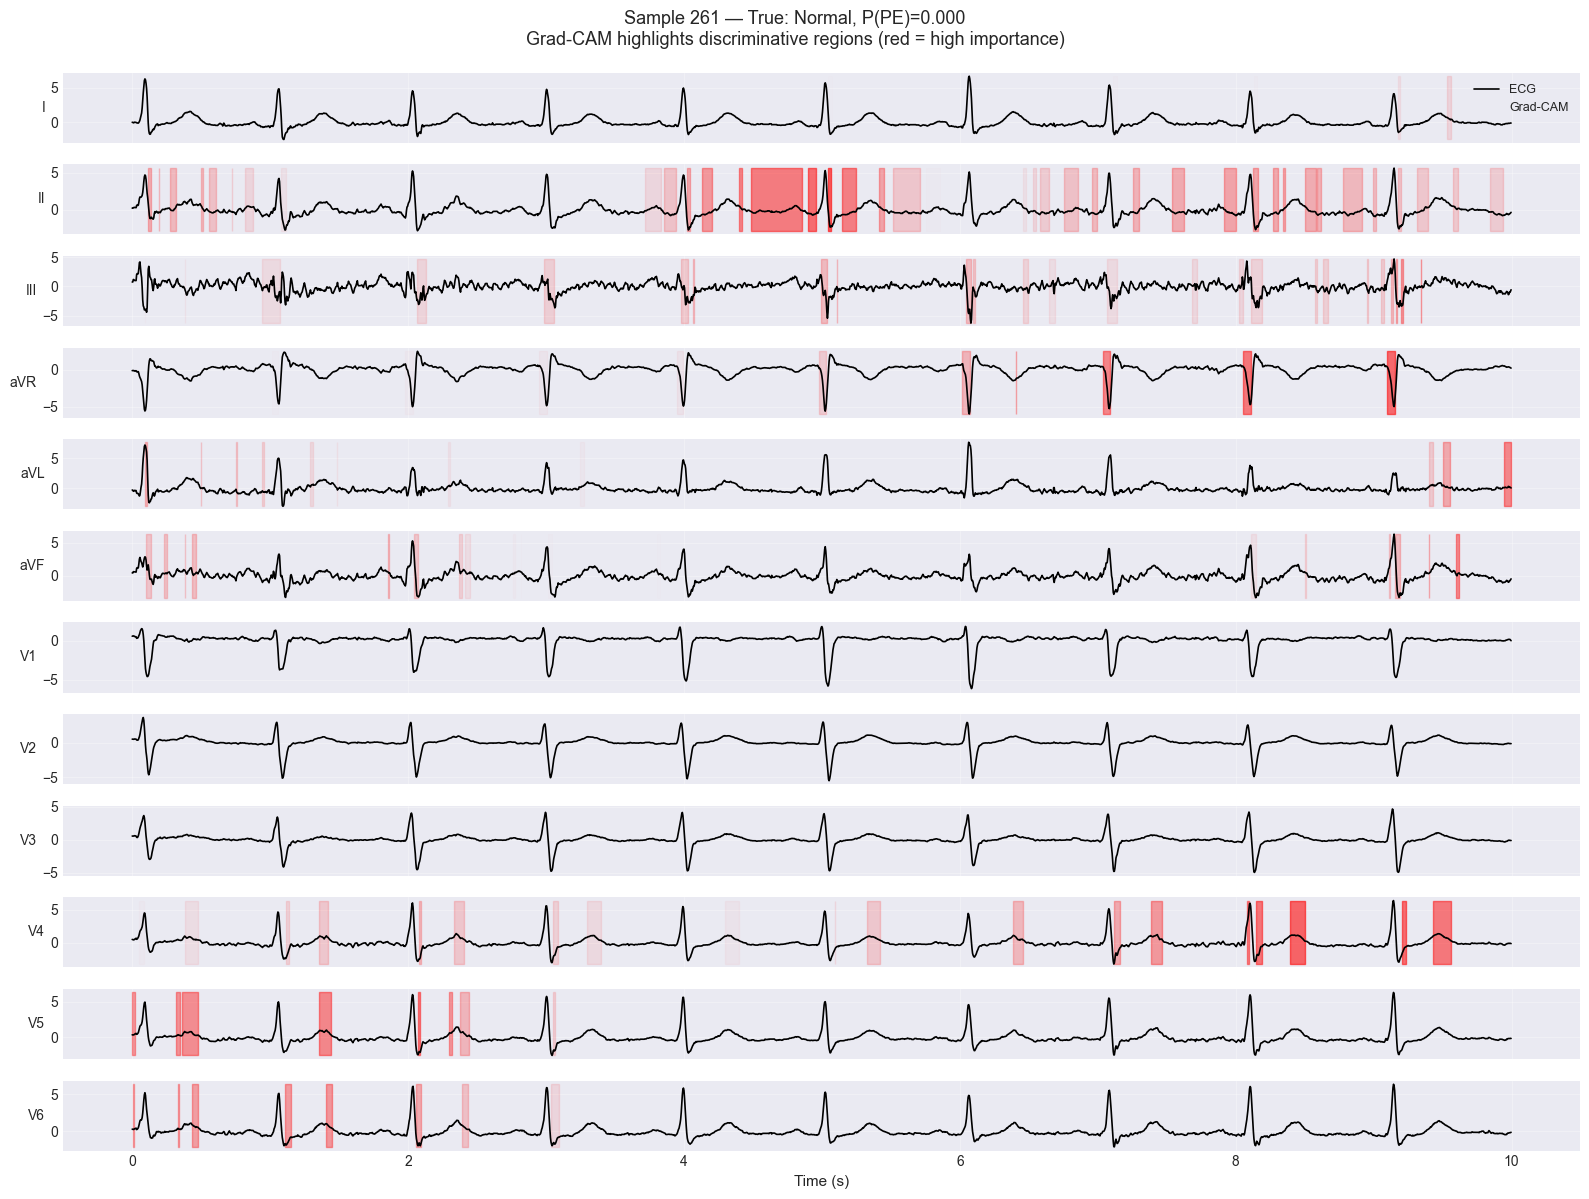


High confidence PREECLAMPSIA prediction


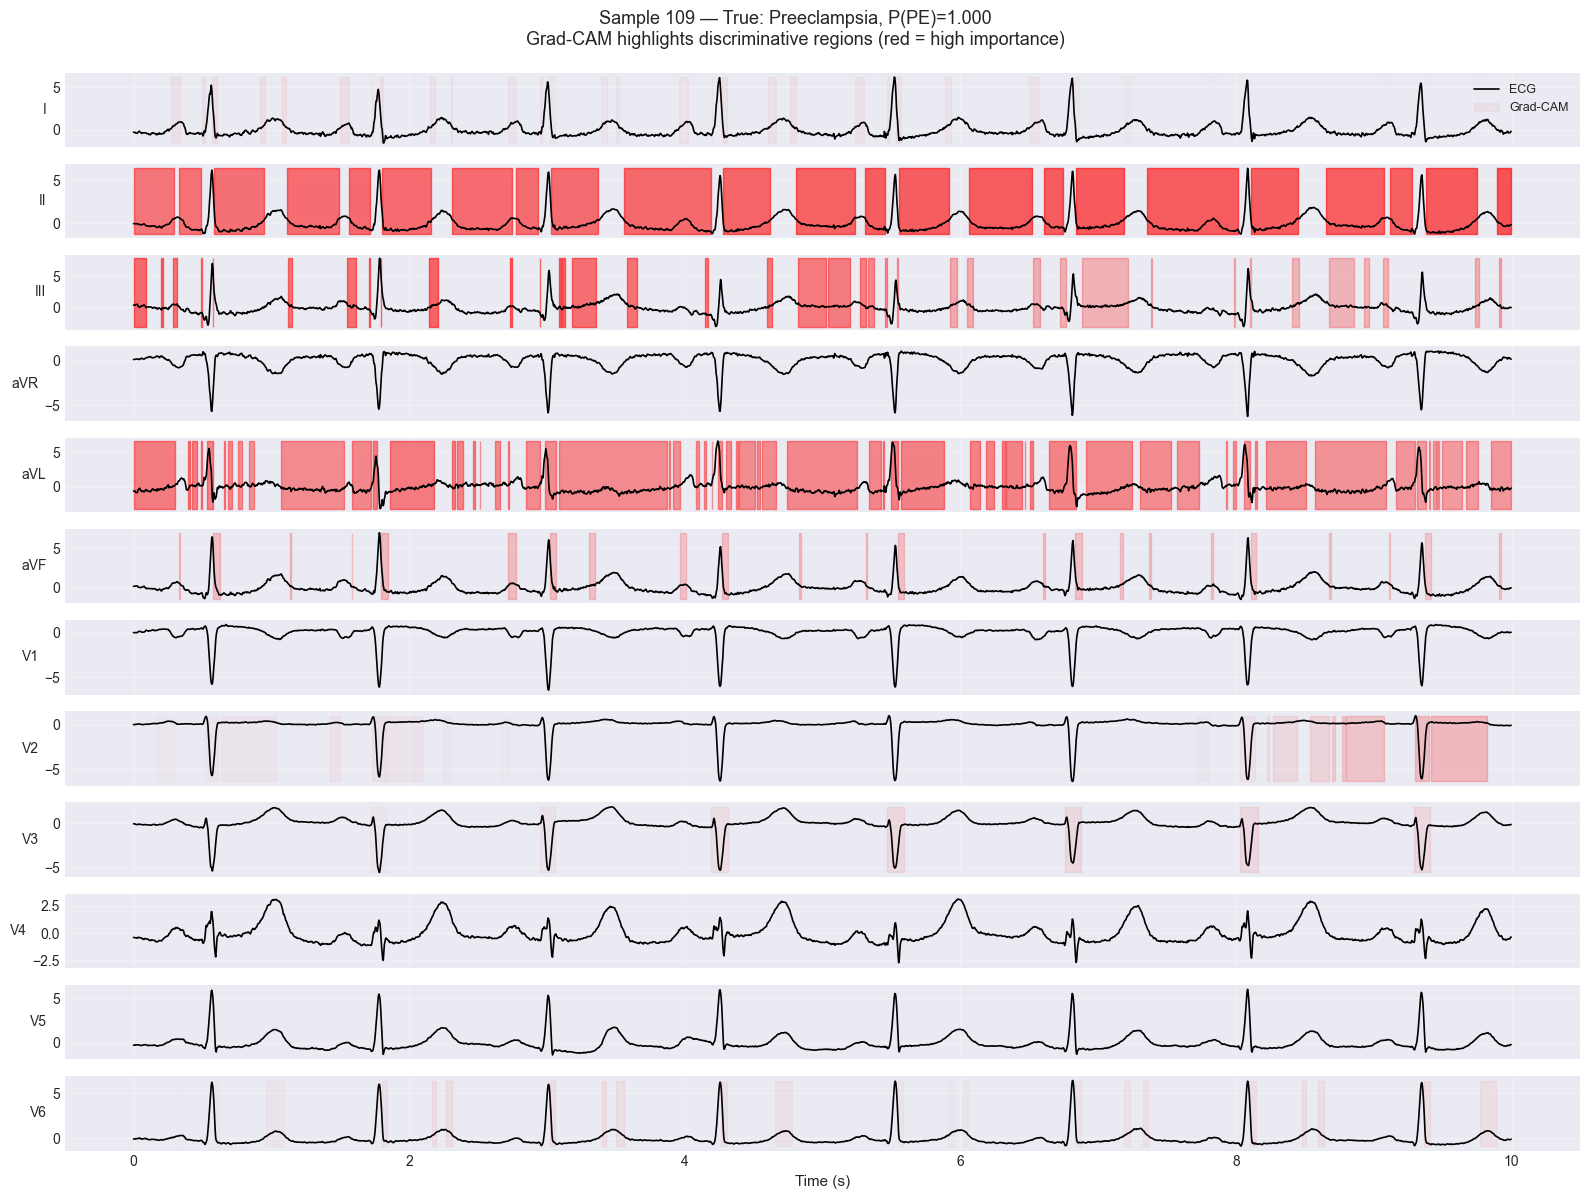


Uncertain prediction


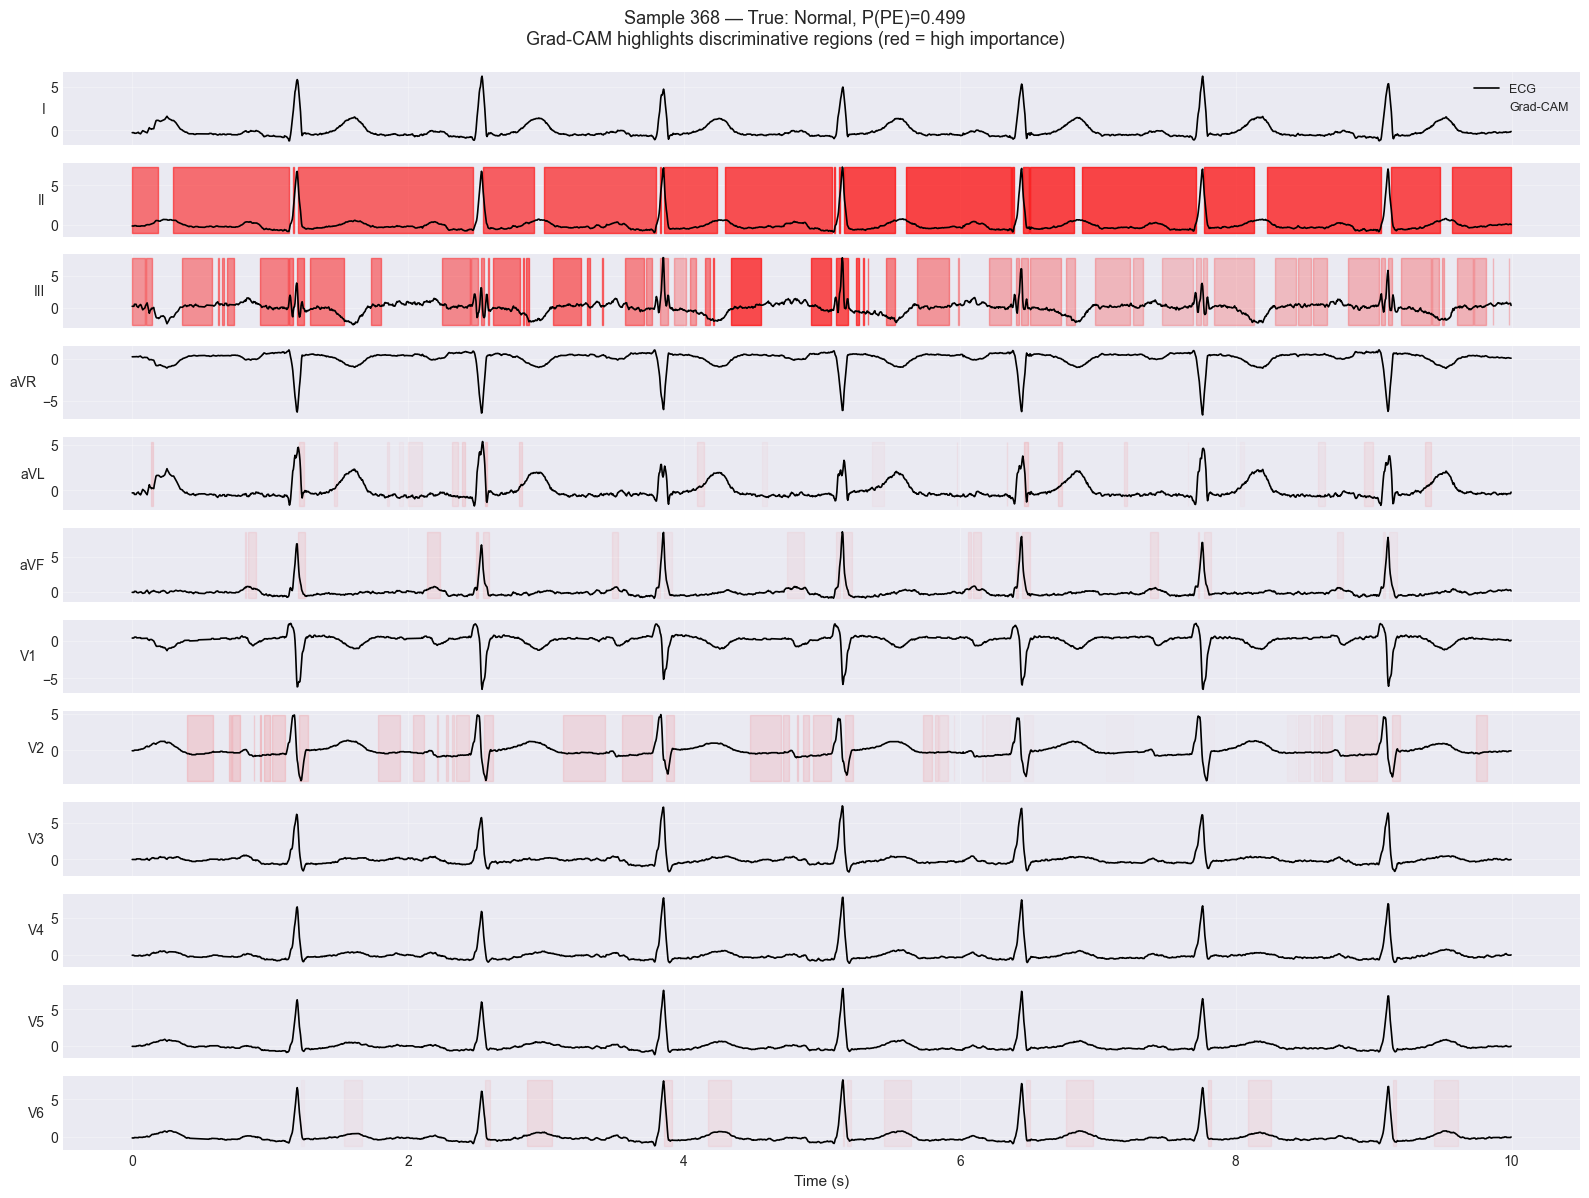

In [8]:
LEAD_NAMES = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
FS = 250.0

def plot_gradcam(sample_idx, X, y, probs, gradcam, upsample_factor=4):
    """
    Plot ECG with Grad-CAM overlay.
    
    Args:
        sample_idx: Index of sample to visualize
        X: ECG data (N, 12, 2500)
        y: True labels
        probs: Model predictions P(preeclampsia)
        gradcam: GradCAM object
        upsample_factor: Upsample CAM to original resolution
    """
    # Get sample
    ecg = X[sample_idx]  # (12, 2500)
    true_label = "Preeclampsia" if y[sample_idx] == 1 else "Normal"
    pred_prob = probs[sample_idx]
    
    # Generate Grad-CAM
    x_tensor = torch.tensor(ecg[np.newaxis], dtype=torch.float32).to(device)
    cam = gradcam(x_tensor, class_idx=1)[0]  # (12, T_cam)
    
    # Upsample CAM to original resolution using interpolation
    from scipy.ndimage import zoom
    cam_upsampled = zoom(cam, (1, upsample_factor), order=1)  # (12, T)
    cam_upsampled = cam_upsampled[:, :ecg.shape[1]]  # trim to exact length
    
    # Time axis
    t = np.arange(ecg.shape[1]) / FS
    
    # Plot
    fig, axes = plt.subplots(12, 1, figsize=(16, 12), sharex=True)
    
    for i, (ax, lead_name) in enumerate(zip(axes, LEAD_NAMES)):
        # Plot ECG signal
        ax.plot(t, ecg[i], color='black', linewidth=1.2, label='ECG', zorder=2)
        
        # Overlay Grad-CAM as colored background
        cam_lead = cam_upsampled[i]
        ax.fill_between(t, ecg[i].min(), ecg[i].max(), 
                        where=cam_lead > 0.3,
                        color='red', alpha=cam_lead, 
                        label='Grad-CAM' if i == 0 else '', zorder=1)
        
        ax.set_ylabel(lead_name, fontsize=10, rotation=0, ha='right', va='center')
        ax.grid(True, alpha=0.3)
        ax.set_ylim(ecg[i].min() - 0.5, ecg[i].max() + 0.5)
    
    axes[-1].set_xlabel("Time (s)", fontsize=11)
    axes[0].legend(loc='upper right', fontsize=9)
    
    fig.suptitle(
        f"Sample {sample_idx} — True: {true_label}, P(PE)={pred_prob:.3f}\n"
        f"Grad-CAM highlights discriminative regions (red = high importance)",
        fontsize=13, y=0.995
    )
    plt.tight_layout()
    plt.show()

# Visualize confident predictions
print("=" * 60)
print("High confidence NORMAL prediction")
print("=" * 60)
plot_gradcam(confident_normal[0], X, y, probs, gradcam)

print("\n" + "=" * 60)
print("High confidence PREECLAMPSIA prediction")
print("=" * 60)
plot_gradcam(confident_preeclampsia[0], X, y, probs, gradcam)

print("\n" + "=" * 60)
print("Uncertain prediction")
print("=" * 60)
plot_gradcam(uncertain_idx[0], X, y, probs, gradcam)

### Lead Importance Heatmap

Aggregate Grad-CAM across multiple samples to see which leads are most important globally.

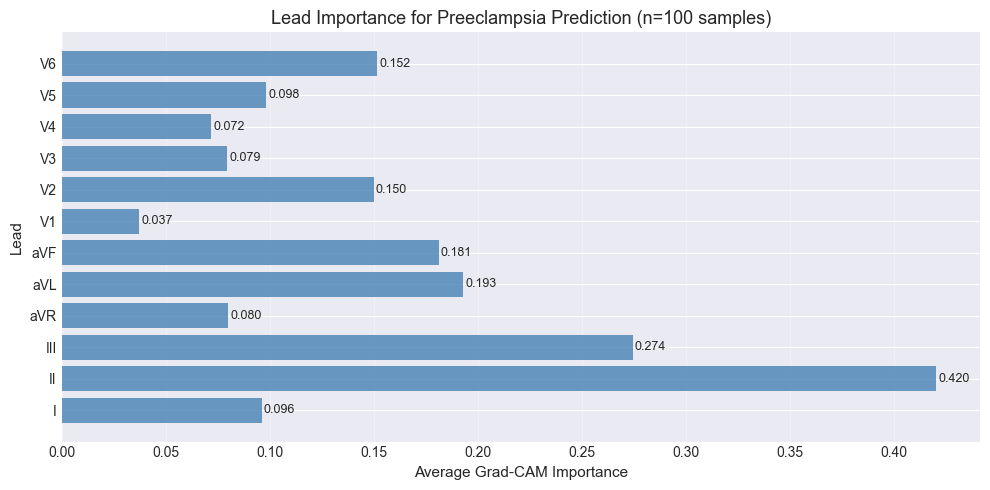


Leads ranked by importance:
   1. II   0.4201
   2. III  0.2743
   3. aVL  0.1930
   4. aVF  0.1812
   5. V6   0.1516
   6. V2   0.1499
   7. V5   0.0982
   8. I    0.0962
   9. aVR  0.0799
  10. V3   0.0795
  11. V4   0.0718
  12. V1   0.0372


In [9]:
def compute_lead_importance(X, y, gradcam, n_samples=50):
    """
    Compute average Grad-CAM importance per lead across samples.
    
    Returns:
        importance: (12,) array of average CAM magnitude per lead
    """
    # Sample stratified indices
    normal_idx = np.where(y == 0)[0]
    pe_idx = np.where(y == 1)[0]
    
    rng = np.random.default_rng(42)
    sample_idx = np.concatenate([
        rng.choice(normal_idx, n_samples // 2, replace=False),
        rng.choice(pe_idx, n_samples // 2, replace=False)
    ])
    
    importance = np.zeros(12)
    
    for idx in sample_idx:
        x_tensor = torch.tensor(X[idx:idx+1], dtype=torch.float32).to(device)
        cam = gradcam(x_tensor, class_idx=1)[0]  # (12, T)
        importance += cam.mean(axis=1)  # average over time
    
    importance /= len(sample_idx)
    return importance

# Compute importance
lead_importance = compute_lead_importance(X, y, gradcam, n_samples=100)

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(LEAD_NAMES, lead_importance, color='steelblue', alpha=0.8)
ax.set_xlabel("Average Grad-CAM Importance", fontsize=11)
ax.set_ylabel("Lead", fontsize=11)
ax.set_title("Lead Importance for Preeclampsia Prediction (n=100 samples)", fontsize=13)
ax.grid(axis='x', alpha=0.3)

# Annotate values
for bar, val in zip(bars, lead_importance):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2, 
            f"{val:.3f}", va='center', fontsize=9)

plt.tight_layout()
plt.show()

# Print ranked leads
print("\nLeads ranked by importance:")
for rank, (lead, imp) in enumerate(sorted(zip(LEAD_NAMES, lead_importance), 
                                         key=lambda x: -x[1]), 1):
    print(f"  {rank:2d}. {lead:3s}  {imp:.4f}")

## 6. Temporal Importance Profile

Aggregate Grad-CAM across leads to see which time regions are most discriminative.

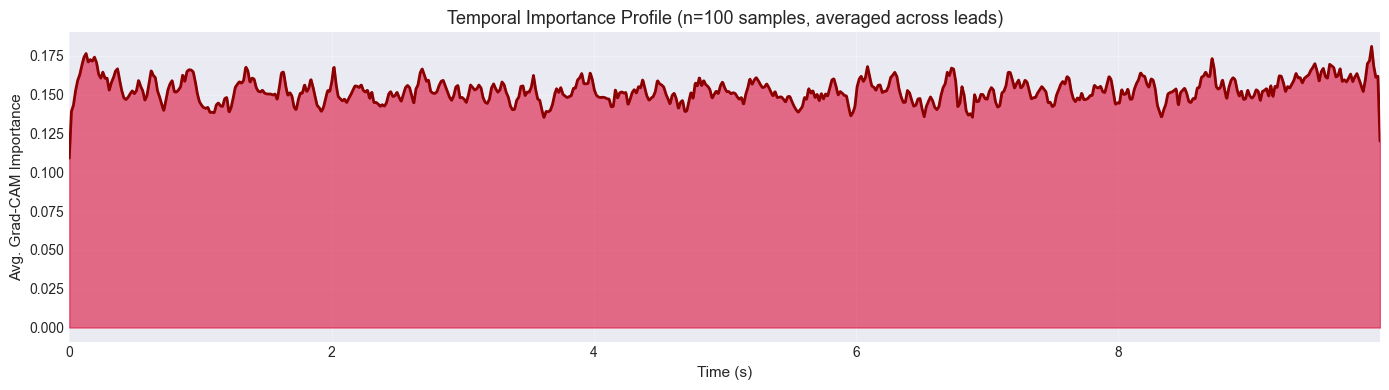


Peak importance at t=9.932s (compare to EDA peak at t=3.344s)


In [10]:
def compute_temporal_profile(X, y, gradcam, n_samples=50, upsample_factor=4):
    """
    Compute average temporal importance profile.
    
    Returns:
        profile: (T,) array of importance over time (averaged across leads and samples)
    """
    from scipy.ndimage import zoom
    
    # Sample stratified indices
    normal_idx = np.where(y == 0)[0]
    pe_idx = np.where(y == 1)[0]
    
    rng = np.random.default_rng(42)
    sample_idx = np.concatenate([
        rng.choice(normal_idx, n_samples // 2, replace=False),
        rng.choice(pe_idx, n_samples // 2, replace=False)
    ])
    
    T = X.shape[2]
    profile = np.zeros(T)
    
    for idx in sample_idx:
        x_tensor = torch.tensor(X[idx:idx+1], dtype=torch.float32).to(device)
        cam = gradcam(x_tensor, class_idx=1)[0]  # (12, T_cam)
        
        # Upsample and average across leads
        cam_up = zoom(cam, (1, upsample_factor), order=1)[:, :T]
        profile += cam_up.mean(axis=0)
    
    profile /= len(sample_idx)
    return profile

# Compute profile
temporal_profile = compute_temporal_profile(X, y, gradcam, n_samples=100)
t = np.arange(len(temporal_profile)) / FS

# Plot
fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(t, 0, temporal_profile, color='crimson', alpha=0.6)
ax.plot(t, temporal_profile, color='darkred', linewidth=2)
ax.set_xlabel("Time (s)", fontsize=11)
ax.set_ylabel("Avg. Grad-CAM Importance", fontsize=11)
ax.set_title("Temporal Importance Profile (n=100 samples, averaged across leads)", fontsize=13)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, t[-1])
plt.tight_layout()
plt.show()

# Find peak time
peak_idx = np.argmax(temporal_profile)
peak_time = t[peak_idx]
print(f"\nPeak importance at t={peak_time:.3f}s (compare to EDA peak at t=3.344s)")

## Summary

This notebook analyzed the RepNet Hybrid model:

1. **Convolutional Kernels**: Visualized learned filters to check if they capture ECG features
2. **Frequency Response**: Verified kernels align with EDA finding (1 Hz discriminative peak)
3. **Inference**: Ran predictions on confident and uncertain cases
4. **Grad-CAM**: Generated saliency maps showing which temporal regions and leads drive predictions
5. **Lead Importance**: Ranked leads by their contribution to classification
6. **Temporal Profile**: Identified key time windows (should align with EDA peak at ~3.3s)

**Key questions to validate**:
- Do kernels show low-frequency (1 Hz) response matching EDA?
- Do Grad-CAM highlights align with known ECG features (P, QRS, T waves)?
- Which leads are most important (compare to EDA Step 9: V5/V6 discriminability)?
- Does temporal peak match EDA finding (t=3.344s)?